In [1]:
# Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

# Why can't LLM spell words? Tokenization.
# Why can't LLM do super simple string processing tasks like reversing a string? Tokenization.
# Why is LLM worse at non-English languages (e.g. Japanese)? Tokenization.
# Why is LLM bad at simple arithmetic? Tokenization.
# Why did GPT-2 have more than necessary trouble coding in Python? Tokenization.
# Why did my LLM abruptly halt when it sees the string "<|endoftext|>"? Tokenization.
# What is this weird warning I get about a "trailing whitespace"? Tokenization.
# Why the LLM break if I ask it about "SolidGoldMagikarp"? Tokenization.
# Why should I prefer to use YAML over JSON with LLMs? Tokenization.
# Why is LLM not actually end-to-end language modeling? Tokenization.
# What is the real root of suffering? Tokenization.



# Tokenization Fundamentals and Importance
# • Tokenization is the process of converting raw text strings into sequences of tokens (integers) that large language models (LLMs) can understand 
#and process.
# • Early naive tokenization approaches use character-level tokenization, mapping each character to an integer token, which leads to long sequences
#and inefficient processing.
# • Modern tokenizers work on subword or byte-level chunks, typically using algorithms such as Byte Pair Encoding (BPE), enabling more efficient 
#token sequences.
# • Tokenization plays a crucial role in model performance; many unusual behaviors or difficulties in LLMs, such as poor spelling, arithmetic,
#or handling of non-English languages, often stem from tokenization issues rather than model architecture.


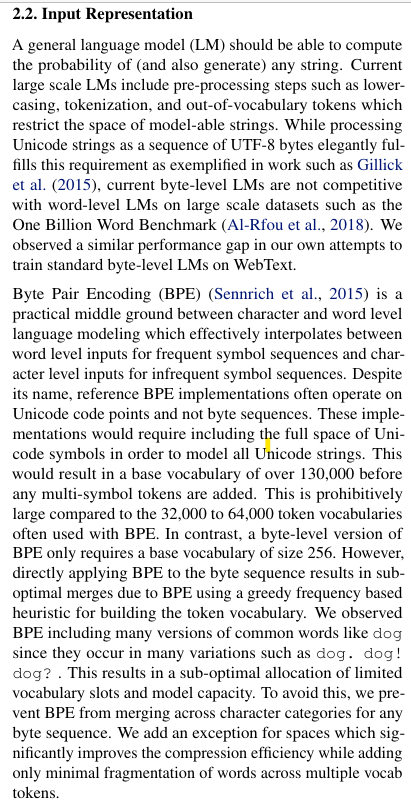

********************************************8


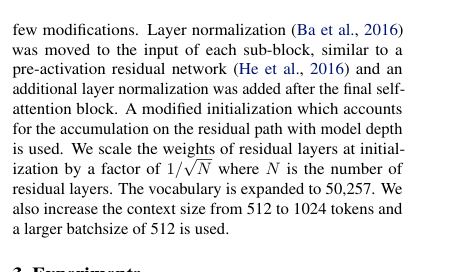

In [4]:
#https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

from IPython.display import Image, display
display(Image(filename='token1.png'))
print("********************************************8")
display(Image(filename='token2.png'))

In [5]:
#https://arxiv.org/pdf/2307.09288

 # 2.1 Pretraining Data
 # Our training corpus includes a new mix of data from publicly available sources, which does not include data
 # from Meta’s products or services. We made an effort to remove data from certain sites known to contain a
 # high volume of personal information about private individuals. We trained on 2 trillion tokens of data as this
 # provides a good performance–cost trade-off, up-sampling the most factual sources in an effort to increase
 # knowledge and dampen hallucinations

In [ ]:
#https://tiktokenizer.vercel.app/

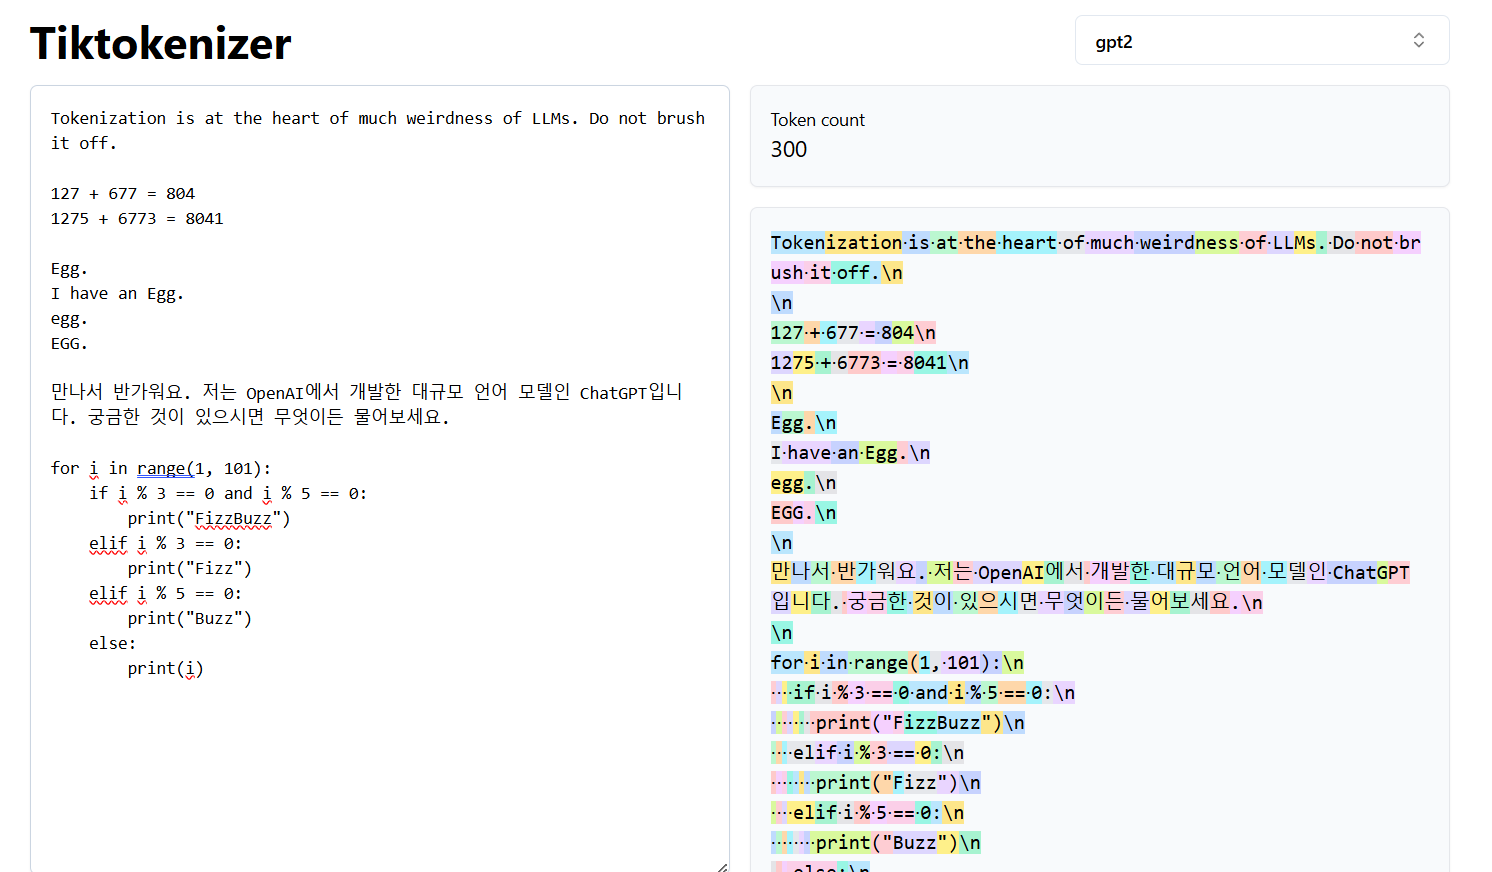

In [6]:
# Examples and Effects of Tokenization in Practice
# • The GPT-2 tokenizer breaks down strings into tokens, sometimes splitting words into multiple tokens arbitrarily (e.g., “tokenization” into two tokens). Spaces are often included as part of tokens.
# • Numbers and arithmetic expressions are tokenized inconsistently; some numbers appear as single tokens, others split across multiple tokens, leading to arbitrary token boundaries.
# • Case sensitivity and whitespace handling affect tokenization; the same word in different contexts (beginning of sentence, lowercase, uppercase) produces different tokens.
# • Non-English languages usually produce longer token sequences due to less efficient token merges, thus bloating input sequences and reducing effective context length.
# • Tokenization inefficiencies impact code understanding as well; e.g., GPT-2 splits every Python space character into a separate token, wasting token budget and reducing context length for code tasks.
# GPT-4’s tokenizer improves on this by merging larger whitespace chunks into single tokens, enhancing efficiency and performance on code-related tasks


from IPython.display import Image, display
display(Image(filename='v1.png'))

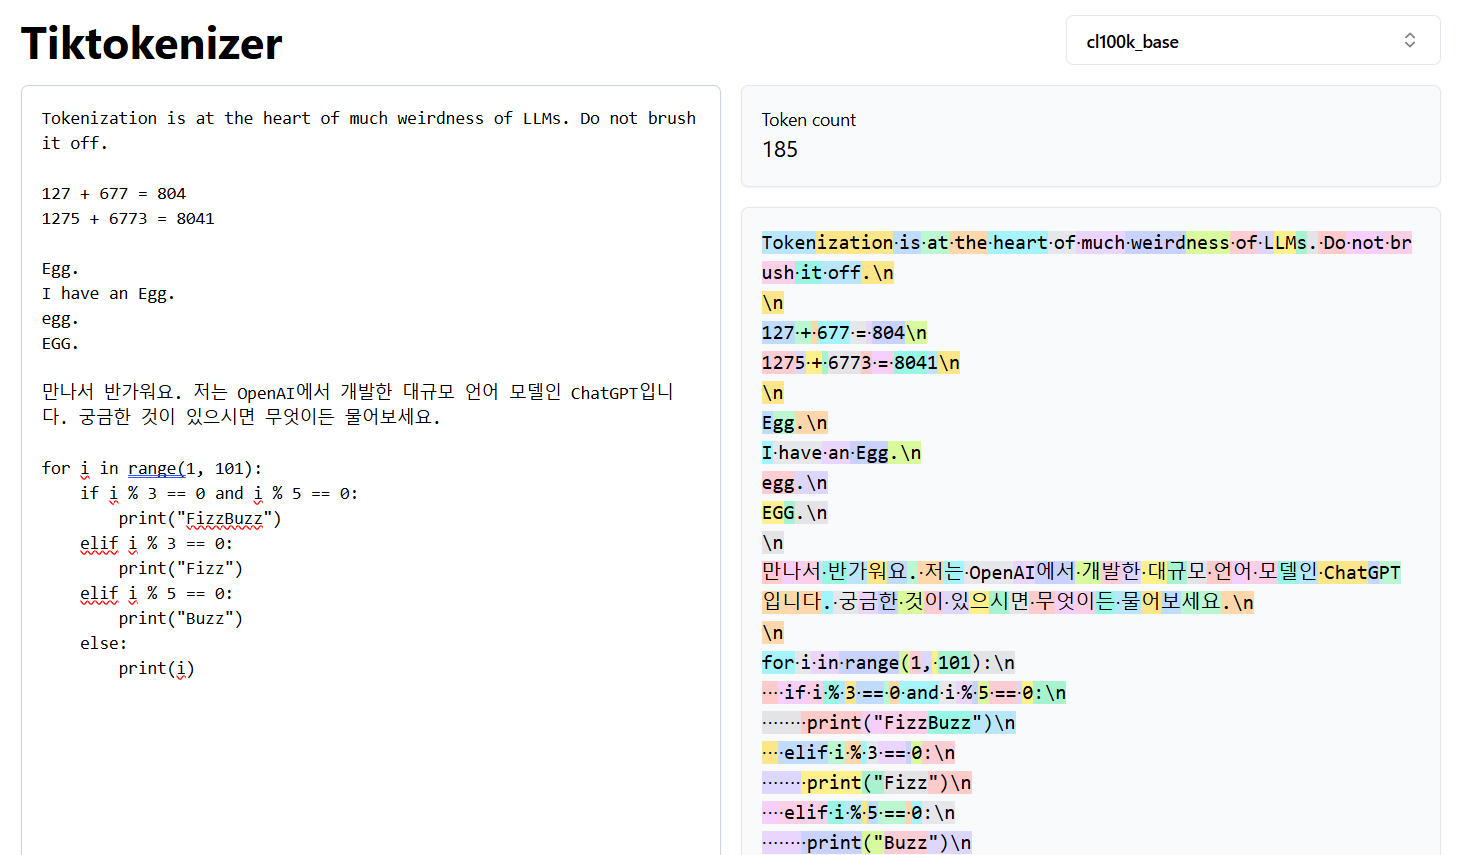

In [7]:
# when I say I have an egg you see when it's a space egg it's two token it's sorry it's a single token so just egg by itself in the beginning of a sentence is two tokens but here as a space egg is suddenly a single token uh for the exact same string okay here lowercase egg turns out to be a single token and in

#this is in Korean and the reason I put this here is because you'll notice that um non-english languages work slightly worse in Chachi part of this is because of course the training data set for Chachi is much larger for English and for everything else but the same is true not just for the large language model itself but also for the tokenizer so when we train the tokenizer we're going to see that there's a training set as well and there's a lot more English than non-english and what ends up happening is that we're going to have a lot more longer tokens for English so how do I put this if you have
#a single sentence in English and you tokenize it you might see that it's 10 tokens or something like that but if you translate that sentence into say Korean or Japanese or something else you'll typically see that the number of tokens used is much larger and that's because the chunks here are a lot more broken up so we're using a lot more tokens for the exact same thing and what this does is it bloats up the sequence length of all the documents so you're using up more tokens and then in the attention of the

#I'd like you to notice is look all these individual spaces are all separate tokens they are token 220 so uh 220 220 220 220 and then space if is a single token and so what's going on here is that when the Transformer is going to consume or try to uh create this text it needs to um handle all these spaces individually they all feed in one by one into the entire
#Transformer in the sequence and so this is being extremely wasteful tokenizing it in this way and so as a result of that gpt2 is not very good with python and it's not anything to do with coding or the language model itself it's just that if he use a lot of indentation using space in Python like we usually do uh you just end up bloating out all the text and it's separated across way too much of the sequence and we are running out of the context length in the sequence uh that's roughly speaking

from IPython.display import Image, display
display(Image(filename='v2.png'))

In [ ]:
#we can change it to CL 100K base which is the GPT for tokenizer and we see that the token count drops to 185 so for the exact same string we are now roughly having the number of tokens and roughly speaking this is because uh the number of tokens in the GPT 4 tokenizer
#is roughly double that of the number of tokens in the gpt2 tokenizer so we went went from roughly 50k to roughly 100K now you can imagine that this is a good thing because the same text is now squished into half as many tokens so uh this is a lot denser input to the Transformer and in the Transformer every single token has a finite number of tokens before it that it's going to pay attention to and so what this is doing is we're roughly able to see twice as much text as a context for what token to



In [ ]:
# Unicode, UTF-8, and the Necessity of Encoding Before Tokenization
# • Text in Python is a sequence of Unicode code points representing over 150,000 characters across many scripts.
# • Unicode code points can be directly converted to integer tokens, but this leads to an enormous vocabulary size and instability due to evolving Unicode standards.
# • Instead, text is encoded into bytes using encodings like UTF-8, UTF-16, or UTF-32, with UTF-8 favored for its backward compatibility and variable-length efficiency.
# • Directly using UTF-8 bytes as tokens (vocab size 256) results in excessively long token sequences, which is inefficient given limited Transformer context.
# • To address this, Byte Pair Encoding (BPE) is applied to compress sequences of bytes into fewer tokens with a larger vocabulary, balancing sequence length and vocabulary size.
# • Tokenization-free autoregressive models are an exciting research direction but currently require architectural changes and remain experimental.


In [ ]:
# let's now start writing some code so remember what we want to do we want to take strings and feed them into language models for that we need to somehow tokenize strings into some integers in some fixed vocabulary and then we will use those integers to make a look up into a lookup table of vectors and feed those vectors into the Transformer as an input now the reason this gets a little bit tricky of course is that we don't just want to support the simple English alphabet we want to
# support different kinds of languages so this is anango in Korean which is hello and we also want to support many kinds of special characters that we might find on the internet for example Emoji so how do we feed this text into uh Transformers well how's the what is this text anyway in Python so if you go to the documentation of a string in Python you can see that strings are immutable sequences of Unicode code points okay what are Unicode code points we can go to PDF so Unicode code points are defined by the Unicode Consortium as


In [8]:
"안녕하세요 👋 (hello in Korean!)"

'안녕하세요 👋 (hello in Korean!)'

In [13]:
ord("h")


104

In [12]:
ord("👋")

128075

In [10]:
ord("hello")

TypeError: ord() expected a character, but string of length 5 found

In [15]:
[ord(x) for x in "안녕하세요 👋 (hello in Korean!)"]

[50504,
 45397,
 54616,
 49464,
 50836,
 32,
 128075,
 32,
 40,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 75,
 111,
 114,
 101,
 97,
 110,
 33,
 41]

In [ ]:
#https://utf8everywhere.org/

In [17]:
"안녕하세요 👋 (hello in Korean!)".encode("utf-8")



b'\xec\x95\x88\xeb\x85\x95\xed\x95\x98\xec\x84\xb8\xec\x9a\x94 \xf0\x9f\x91\x8b (hello in Korean!)'

In [18]:
list("안녕하세요 👋 (hello in Korean!)".encode("utf-8"))

[236,
 149,
 136,
 235,
 133,
 149,
 237,
 149,
 152,
 236,
 132,
 184,
 236,
 154,
 148,
 32,
 240,
 159,
 145,
 139,
 32,
 40,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 75,
 111,
 114,
 101,
 97,
 110,
 33,
 41]

In [19]:
list("안녕하세요 👋 (hello in Korean!)".encode("utf-16"))

[255,
 254,
 72,
 197,
 85,
 177,
 88,
 213,
 56,
 193,
 148,
 198,
 32,
 0,
 61,
 216,
 75,
 220,
 32,
 0,
 40,
 0,
 104,
 0,
 101,
 0,
 108,
 0,
 108,
 0,
 111,
 0,
 32,
 0,
 105,
 0,
 110,
 0,
 32,
 0,
 75,
 0,
 111,
 0,
 114,
 0,
 101,
 0,
 97,
 0,
 110,
 0,
 33,
 0,
 41,
 0]

In [ ]:
#something we're starting to get a sense that this is a bit of a wasteful encoding and indeed for simple asky characters or English characters here uh we just have the structure of 0 something Z something and it's not exactly nice same for UTF 32 when we expand this we can start to get a sense of the wastefulness of this encoding for our purposes you see a lot of zeros
#followed by something and so uh this is not desirable so suffice it to say that we would like to stick with utf8 for our purposes however if we just use utf8 naively these are by streams so that would imply a vocabulary length of only 256 possible tokens uh but this this vocabulary size is very very small what this is going to do if we just were to use it naively is that all of our text would be stretched out over very very long sequences of bytes an

In [ ]:
#stick with utf-8
#https://arxiv.org/pdf/2305.07185
#https://en.wikipedia.org/wiki/Byte-pair_encoding

In [ ]:
#  Byte Pair Encoding (BPE) Algorithm and Tokenizer Training
# • BPE iteratively merges the most frequent pairs of tokens into new tokens, expanding the vocabulary while compressing input sequences.
# • Starting from a vocabulary of raw bytes (256 tokens), the algorithm identifies frequent byte pairs, merges them, and adds the new merged tokens to the vocabulary.
# • Each merge reduces sequence length but increases vocabulary size, finding a balance between compactness and vocabulary complexity.
# • Implementation involves counting pair frequencies, replacing pairs with new tokens, and repeating for a fixed number of merges (hyperparameter).
# • Compression ratios improve with more merges, but diminishing returns apply.
# • The tokenizer training is a separate preprocessing step from the LLM training and typically uses its own training data, which influences token merges and tokenization efficiency.
# • The tokenizer acts as a bidirectional translator between raw text and token sequences, enabling both encoding and decoding.


In [20]:
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience
print('---')
print(text)
print("length:", len(text))
print('---')
print(tokens)
print("length:", len(tokens))

---
Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.
length: 533
---
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140

In [22]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]): # Pythonic way to iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats = get_stats(tokens)
print(stats)
# this is the dictionary the keys are these topples of consecutive elements and this
#is the count so just to uh print it in a slightly better way this is one way that 
#I like to do that where you it's a little bit compound here so you can pause if you 
#like but we
#iterate all all the items the items
# print(sorted(((v,k) for k,v in stats.items()), reverse=True))

{(239, 188): 1, (188, 181): 1, (181, 239): 1, (239, 189): 6, (189, 142): 1, (142, 239): 1, (189, 137): 1, (137, 239): 1, (189, 131): 1, (131, 239): 1, (189, 143): 1, (143, 239): 1, (189, 132): 1, (132, 239): 1, (189, 133): 1, (133, 33): 1, (33, 32): 2, (32, 240): 3, (240, 159): 15, (159, 133): 7, (133, 164): 1, (164, 240): 1, (133, 157): 1, (157, 240): 1, (133, 152): 1, (152, 240): 1, (133, 146): 1, (146, 240): 1, (133, 158): 1, (158, 240): 1, (133, 147): 1, (147, 240): 1, (133, 148): 1, (148, 226): 1, (226, 128): 12, (128, 189): 1, (189, 32): 1, (159, 135): 7, (135, 186): 1, (186, 226): 1, (128, 140): 6, (140, 240): 6, (135, 179): 1, (179, 226): 1, (135, 174): 1, (174, 226): 1, (135, 168): 1, (168, 226): 1, (135, 180): 1, (180, 226): 1, (135, 169): 1, (169, 226): 1, (135, 170): 1, (170, 33): 1, (159, 152): 1, (152, 132): 1, (132, 32): 1, (32, 84): 1, (84, 104): 1, (104, 101): 6, (101, 32): 20, (32, 118): 1, (118, 101): 3, (101, 114): 6, (114, 121): 2, (121, 32): 2, (32, 110): 2, (110,

In [23]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]): # Pythonic way to iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats = get_stats(tokens)
print(sorted(((v,k) for k,v in stats.items()), reverse=True))

[(20, (101, 32)), (15, (240, 159)), (12, (226, 128)), (12, (105, 110)), (10, (115, 32)), (10, (97, 110)), (10, (32, 97)), (9, (32, 116)), (8, (116, 104)), (7, (159, 135)), (7, (159, 133)), (7, (97, 114)), (6, (239, 189)), (6, (140, 240)), (6, (128, 140)), (6, (116, 32)), (6, (114, 32)), (6, (111, 114)), (6, (110, 103)), (6, (110, 100)), (6, (109, 101)), (6, (104, 101)), (6, (101, 114)), (6, (32, 105)), (5, (117, 115)), (5, (115, 116)), (5, (110, 32)), (5, (100, 101)), (5, (44, 32)), (5, (32, 115)), (4, (116, 105)), (4, (116, 101)), (4, (115, 44)), (4, (114, 105)), (4, (111, 117)), (4, (111, 100)), (4, (110, 116)), (4, (110, 105)), (4, (105, 99)), (4, (104, 97)), (4, (103, 32)), (4, (101, 97)), (4, (100, 32)), (4, (99, 111)), (4, (97, 109)), (4, (85, 110)), (4, (32, 119)), (4, (32, 111)), (4, (32, 102)), (4, (32, 85)), (3, (118, 101)), (3, (116, 115)), (3, (116, 114)), (3, (116, 111)), (3, (114, 116)), (3, (114, 115)), (3, (114, 101)), (3, (111, 102)), (3, (111, 32)), (3, (108, 108)), (

In [24]:
#his is the dictionary the keys are these topples of consecutive elements and this is the 
# count so just to uh print it in a slightly better way this is one way that I like to do that
# where you it's a little bit compound here so you can pause if you like but we iterate all 
# all the items the items
#called on dictionary returns pairs of key value and instead I create a list here of value
# key because if it's a value key list then I can call sort on it and by default python will
# uh use the first element which in this case will be value to sort by if it's given tles and
# then reverse so it's descending and print that so basically it looks like 101 comma 32 was
# the most commonly occurring consecutive pair and it occurred 20 times we can double 
# check that that makes reasonable sense so if I
#101,32 -> 20 occurences

In [25]:
chr(101),chr(32) #(e<space>)

('e', ' ')

In [26]:
top_pair = max(stats, key=stats.get)
top_pair

(101, 32)

In [29]:
def merge(ids, pair, idx):
  # in the list of ints (ids), replace all consecutive occurences of pair with the new token idx
  newids = []
  i = 0
  while i < len(ids):
    # if we are not at the very last position AND the pair matches, replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

print(merge([5, 6, 6, 7, 9, 1], (6, 7), 99))

#tokens2 = merge(tokens, top_pair, 256)
#print(tokens2)
#print("length:", len(tokens2))

[5, 6, 99, 9, 1]


In [30]:
def merge(ids, pair, idx):
  # in the list of ints (ids), replace all consecutive occurences of pair with the new token idx
  newids = []
  i = 0
  while i < len(ids):
    # if we are not at the very last position AND the pair matches, replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

#print(merge([5, 6, 6, 7, 9, 1], (6, 7), 99))

tokens2 = merge(tokens, top_pair, 256)
print(tokens2)
print("length:", len(tokens2))

[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140, 240, 159, 135, 169, 226, 128, 140, 240, 159, 135, 170, 33, 32, 240, 159, 152, 132, 32, 84, 104, 256, 118, 101, 114, 121, 32, 110, 97, 109, 256, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 256, 105, 110, 116, 111, 32, 116, 104, 256, 104, 101, 97, 114, 116, 115, 32, 111, 102, 32, 112, 114, 111, 103, 114, 97, 109, 109, 101, 114, 115, 32, 119, 111, 114, 108, 100, 119, 105, 100, 101, 46, 32, 87, 256, 97, 108, 108, 32, 107, 110, 111, 119, 32, 119, 256, 111, 117, 103, 104, 116, 32, 116, 111, 32, 226, 128, 156

In [ ]:
#256->20 occurences , no occurences of 101,32

In [31]:
# making the training text longer to have more representative token statistics
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = """A Programmer’s Introduction to Unicode March 3, 2017 · Coding · 22 Comments  Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.  A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.  I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.  Diversity and Inherent Complexity The Unicode Codespace Codespace Allocation Scripts Usage Frequency Encodings UTF-8 UTF-16 Combining Marks Canonical Equivalence Normalization Forms Grapheme Clusters And More… Diversity and Inherent Complexity As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.  When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”  However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.  Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.  Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.  Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!  The Unicode Codespace Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.  The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.  Codespace Allocation To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.  Map of the Unicode codespace (click to zoom)  White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.  Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.  (In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)  Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.  Scripts Let’s zoom in on the first three planes, since that’s where the action is:  Map of scripts in Unicode planes 0–2 (click to zoom)  This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.  Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).  Usage Frequency One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.  Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)  You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.  Encodings We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?  The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.  Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.  Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.  UTF-8 In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.  UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:  UTF-8 (binary)\tCode point (binary)\tRange 0xxxxxxx\txxxxxxx\tU+0000–U+007F 110xxxxx 10yyyyyy\txxxxxyyyyyy\tU+0080–U+07FF 1110xxxx 10yyyyyy 10zzzzzz\txxxxyyyyyyzzzzzz\tU+0800–U+FFFF 11110xxx 10yyyyyy 10zzzzzz 10wwwwww\txxxyyyyyyzzzzzzwwwwww\tU+10000–U+10FFFF A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.  Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.  However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.  UTF-16 The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.  Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:  UTF-16 (binary)\tCode point (binary)\tRange xxxxxxxxxxxxxxxx\txxxxxxxxxxxxxxxx\tU+0000–U+FFFF 110110xxxxxxxxxx 110111yyyyyyyyyy\txxxxxxxxxxyyyyyyyyyy + 0x10000\tU+10000–U+10FFFF A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.  Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.  Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)  By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)  Combining Marks In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!  Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.  In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.  If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.  For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.  Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.  Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓  A few other places where dynamic character composition shows up in Unicode:  Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.  A Hebrew example, with niqqud:\tאֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד Normal writing (no niqqud):\tאת דלתי הזיז הניע, קטב לשכתי ישוד Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “\u200bि” = “हि” (“h” + “i” = “hi”). Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”). Canonical Equivalence In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.  Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.  For example, the Vietnamese letter “ệ” can be expressed in five different ways:  Fully precomposed: U+1EC7 “ệ” Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂” Partially precomposed: U+00EA “ê” + U+0323 “◌̣” Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂” Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣” Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!  Normalization Forms To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).  The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)  The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).  There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.  Grapheme Clusters As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.  UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.  The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.  Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.  And More… There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.  Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.  Further reading:  The Unicode Standard UTF-8 Everywhere Manifesto Dark corners of Unicode by Eevee ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things Python 3 Unicode Howto Google Noto Fonts—set of fonts intended to cover all assigned code points"""
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience

In [32]:
#merging in a loop

def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx):
  newids = []
  i = 0
  while i < len(ids):
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

# ---
vocab_size = 276 # the desired final vocabulary size
num_merges = vocab_size - 256
ids = list(tokens) # copy so we don't destroy the original list

merges = {} # (int, int) -> int
for i in range(num_merges):
  stats = get_stats(ids)
  pair = max(stats, key=stats.get)
  idx = 256 + i
  print(f"merging {pair} into a new token {idx}")
  ids = merge(ids, pair, idx)
  merges[pair] = idx

merging (101, 32) into a new token 256
merging (105, 110) into a new token 257
merging (115, 32) into a new token 258
merging (116, 104) into a new token 259
merging (101, 114) into a new token 260
merging (99, 111) into a new token 261
merging (116, 32) into a new token 262
merging (226, 128) into a new token 263
merging (44, 32) into a new token 264
merging (97, 110) into a new token 265
merging (111, 114) into a new token 266
merging (100, 32) into a new token 267
merging (97, 114) into a new token 268
merging (101, 110) into a new token 269
merging (257, 103) into a new token 270
merging (261, 100) into a new token 271
merging (121, 32) into a new token 272
merging (46, 32) into a new token 273
merging (97, 108) into a new token 274
merging (259, 256) into a new token 275


In [34]:
print("tokens length:", len(tokens))
print("ids length:", len(ids))
print(f"compression ratio: {len(tokens) / len(ids):.2f}X")

tokens length: 24597
ids length: 19438
compression ratio: 1.27X


In [33]:
#this is the code that I came up with uh to actually do the merging in Loop these two functions here are identical to what we had above I only included them here just so that you have the point of reference here so uh these two are identical and then this is the new code that I added so the first first thing we want to do is we want to decide on the final vocabulary size that we want our tokenizer to have and as I mentioned this is a hyper parameter and you set it in some way depending on your best
#performance so let's say for us we're going to use 276 because that way we're going to be doing exactly 20 merges and uh 20 merges because we already have 256 tokens for the raw bytes and to reach 276 we have to do 20 merges uh to add 20 new tokens here uh this is uh one way in Python to just create a copy of a list so I'm taking the tokens list and by wrapping it in a list python will construct a new list of all the individual elements so this is just a copy operation then here I'm creating a
#merges uh dictionary so this merges dictionary is going to maintain basically the child one child two mapping to a new uh token and so what we're going to be building up here is a binary tree of merges but actually it's not exactly a tree because a tree would have a single root node with a bunch of leaves for us we're starting with the leaves on the bottom which are the individual bites those are the starting 256 tokens and then we're starting to like merge two of them at a time and so
#it's not a tree it's more like a forest um uh as we merge these elements so for 20 merges we're going to find the most commonly occurring pair we're going to Mint a new token integer for it so I here will start at zero so we'll going to start at 256 we're going to print that we're merging it and we're going to replace all of the occurrences of that pair with the new new lied token and we're going to record that this pair of integers merged into this new integer so running this gives us the
#following output so we did 20 merges and for example the first merge was exactly as before the 10132 um tokens merging into a new token 2556 now keep in mind that the individual uh tokens 101 and 32 can still occur in the sequence after merging it's only when they occur exactly consecutively that that becomes 256 now um and in particular the other thing to notice here is that the token 256 which is the newly minted token is also eligible for merging so here on the bottom the 20th merge was a merge of 25
#and 259 becoming 275 so every time we replace these tokens they become eligible for merging in the next round of data ration so that's why we're building up a small sort of binary Forest instead of a single individual tree one thing we can take a look at as well is we can take a look at the compression ratio that we've achieved so in particular we started off with this tokens list um so we started off with 24,000 bytes and after merging 20 times uh we now have only 19,000 um tokens and so therefore the


In [38]:
#Note, the Tokenizer is a completely separate, independent module from the LLM. It has its own training dataset of text (which could be different from that of the LLM), on which you train the vocabulary using the Byte Pair Encoding (BPE) algorithm. It then translates back and forth between raw text and sequences of tokens. The LLM later only ever sees the tokens and never directly deals with any text.

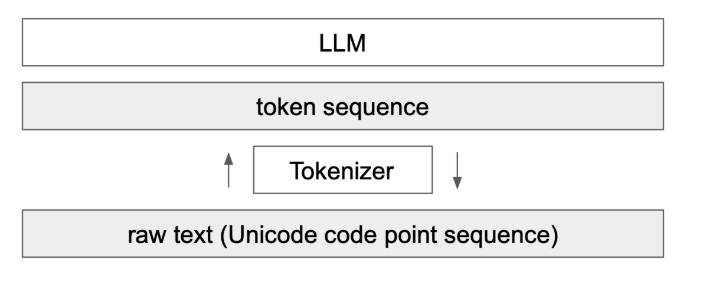

In [39]:
from IPython.display import Image, display
display(Image(filename='token3.png'))

In [40]:
# Encoding and Decoding with BPE Merges
# • Decoding involves reconstructing raw text from token sequences by recursively expanding merged tokens back into their constituent byte sequences and decoding bytes into UTF-8 strings.
# • Decoding must handle invalid UTF-8 byte sequences gracefully using error handling (e.g., replacing invalid bytes with a replacement character) to avoid crashes.
# • Encoding converts raw text to token sequences by encoding text into UTF-8 bytes and iteratively merging byte pairs according to the learned merges dictionary.
# • The merge order is critical: earlier merges must be applied before later ones to correctly compress the byte sequence.
# • Encoding stops when no further merges are possible, yielding the final token sequence.
# • Edge cases like empty or single-character strings must be handled properly to avoid errors.
# • Round-trip tests (encode then decode) confirm correctness of tokenizer implementation.


In [43]:
vocab = {idx: bytes([idx]) for idx in range(256)}
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

def decode(ids):
  # given ids (list of integers), return Python string
  tokens = b"".join(vocab[idx] for idx in ids)
  text = tokens.decode("utf-8", errors="replace")
  return text

print(decode([128]))
print(decode([97]))

�
a


In [44]:
#so we begin with the raw bytes for tokens from 0 to 255 and then we go in order of all the merges and we sort of uh populate this vocab list by doing an addition here so this is the basically the bytes representation of the first child followed by the second one and remember these are bytes objects so this addition here is an addition of two bytes objects just concatenation so that's what we get here one tricky thing to be careful with by the way is that I'm iterating a
#dictionary in Python using a DOT items and uh it really matters that this runs in the order in which we inserted items into the merous dictionary luckily starting with python 3.7 this is guaranteed to be the case but before python 3.7 this iteration may have been out of order with respect to how we inserted elements into merges and this may not have worked but we are using an um modern python so we're okay and then here uh given the IDS the first thing we're going to do is get the tokens so the way I implemented this


In [46]:
merges

{(101, 32): 256,
 (105, 110): 257,
 (115, 32): 258,
 (116, 104): 259,
 (101, 114): 260,
 (99, 111): 261,
 (116, 32): 262,
 (226, 128): 263,
 (44, 32): 264,
 (97, 110): 265,
 (111, 114): 266,
 (100, 32): 267,
 (97, 114): 268,
 (101, 110): 269,
 (257, 103): 270,
 (261, 100): 271,
 (121, 32): 272,
 (46, 32): 273,
 (97, 108): 274,
 (259, 256): 275}

In [47]:
stats

{(65, 32): 8,
 (32, 80): 7,
 (80, 114): 1,
 (114, 111): 57,
 (111, 103): 23,
 (103, 114): 25,
 (114, 97): 40,
 (97, 109): 47,
 (109, 109): 20,
 (109, 260): 10,
 (260, 263): 6,
 (263, 153): 64,
 (153, 258): 29,
 (258, 73): 3,
 (73, 110): 15,
 (110, 116): 18,
 (116, 114): 50,
 (111, 100): 18,
 (100, 117): 8,
 (117, 99): 19,
 (99, 116): 62,
 (116, 105): 134,
 (105, 111): 76,
 (111, 110): 143,
 (110, 32): 78,
 (32, 116): 66,
 (116, 111): 110,
 (111, 32): 137,
 (32, 85): 66,
 (85, 110): 60,
 (110, 105): 71,
 (105, 271): 59,
 (271, 256): 111,
 (256, 77): 3,
 (77, 268): 3,
 (268, 99): 4,
 (99, 104): 89,
 (104, 32): 45,
 (32, 51): 5,
 (51, 264): 2,
 (264, 50): 1,
 (50, 48): 1,
 (48, 49): 7,
 (49, 55): 2,
 (55, 32): 5,
 (32, 194): 2,
 (194, 183): 2,
 (183, 32): 2,
 (32, 67): 8,
 (67, 111): 17,
 (100, 270): 7,
 (270, 32): 107,
 (32, 50): 3,
 (50, 50): 1,
 (50, 32): 14,
 (111, 109): 43,
 (109, 269): 10,
 (269, 116): 36,
 (116, 258): 68,
 (258, 32): 1,
 (32, 239): 1,
 (239, 188): 1,
 (188, 181): 1

In [50]:
def encode(text):
  # given a string, return list of integers (the tokens)
  tokens = list(text.encode("utf-8"))
#  while len(tokens) >= 2:
  while True:
    stats = get_stats(tokens)
    pair = min(stats, key=lambda p: merges.get(p, float("inf")))
    if pair not in merges:
      break # nothing else can be merged
    idx = merges[pair]
    tokens = merge(tokens, pair, idx)
  return tokens

print(encode("hello world!"))
#print(encode("h")) while len(tokens) >=2

[104, 101, 108, 108, 111, 32, 119, 266, 108, 100, 33]


In [51]:
print(decode(encode("hello world")))

hello world


In [52]:
text2 = decode(encode(text))
print(text2 == text)

True


In [53]:
valtext = "Many common characters, including numerals, punctuation, and other symbols, are unified within the standard and are not treated as specific to any given writing system. Unicode encodes thousands of emoji, with the continued development thereof conducted by the Consortium as a part of the standard.[4] Moreover, the widespread adoption of Unicode was in large part responsible for the initial popularization of emoji outside of Japan. Unicode is ultimately capable of encoding more than 1.1 million characters."
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


In [54]:

# GPT-2 Tokenizer and Regular Expression Splitting
# • GPT-2 tokenizer does not naively apply BPE across all text; it first splits text into chunks using a complex regular expression that separates letters, numbers, punctuation, and whitespace.
# • This chunking prevents merges across certain character boundaries, e.g., letters are not merged with punctuation, avoiding tokens like “dog.” or “dog!”, which would bloat the vocabulary unnecessarily.
# • The regular expression handles apostrophes and whitespace carefully, though it has language-specific quirks and case sensitivity issues.
# • Spaces are often tokenized separately to maintain consistent tokenization patterns.
# • The GPT-2 tokenizer code released by OpenAI is inference-only (no training code), making exact reproduction of training merges difficult.
# • OpenAI’s TikToken library provides efficient inference tokenization for GPT-2 and GPT-4 tokenizers, with GPT-4 showing improved whitespace handling and larger vocabulary (~100K tokens vs 50K for GPT-2).
#https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

In [57]:
#Forced splits using regex patterns (GPT series)
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "Hello've world123 how's are you!!!?"))

['Hello', "'ve", ' world', '123', ' how', "'s", ' are', ' you', '!!!?']


In [58]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "Hello world"))

['Hello', ' world']


In [66]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "12324GPu mak45'3 `sds how's how`s!!!?     nike   "))

['12324', 'GPu', ' mak', '45', "'", '3', ' `', 'sds', ' how', "'s", ' how', '`', 's', '!!!?', '    ', ' nike', '   ']


In [67]:
example = """
for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
"""
print(re.findall(gpt2pat, example))

['\n', 'for', ' i', ' in', ' range', '(', '1', ',', ' 101', '):', '\n   ', ' if', ' i', ' %', ' 3', ' ==', ' 0', ' and', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'FizzBuzz', '")', '\n   ', ' elif', ' i', ' %', ' 3', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Fizz', '")', '\n   ', ' elif', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Buzz', '")', '\n   ', ' else', ':', '\n       ', ' print', '(', 'i', ')', '\n']


In [9]:
# TikToken Library, Special Tokens, and Vocabulary Management
# • TikToken is OpenAI’s official tokenizer library supporting GPT-family tokenizers; it handles encoding, decoding, and special tokens.
# • Special tokens (e.g., end-of-text, start/end of messages) are outside the normal BPE merges and have dedicated token IDs, used extensively in fine-tuning and chat models.
# • Adding new special tokens requires model surgery: expanding the embedding matrix and output layers to accommodate new IDs, usually initialized randomly.
# • TikToken uses regular expressions for chunking text before merging tokens, which evolved from GPT-2 to GPT-4 to fix case and whitespace inconsistencies.
# • The GPT-4 tokenizer merges longer whitespace sequences into single tokens, improving tokenization density and model efficiency, especially for code.
# • The GPT-2 encoder JSON and BPE merges files correspond exactly to the vocab and merge dictionaries used in the tokenizer implementation.
# • The tokenizer is conceptually separate from the LLM model; it has its own training data and hyperparameters, impacting token distribution and model input length.
#1:11:42

In [2]:
import tiktoken

# GPT-2 (does not merge spaces)
enc = tiktoken.get_encoding("gpt2")
print(enc.encode("    hello world!!!"))

# GPT-4 (merges spaces)
enc = tiktoken.get_encoding("cl100k_base")
print(enc.encode("    hello world!!!"))

[220, 220, 220, 23748, 995, 10185]
[262, 24748, 1917, 12340]


In [3]:
# #Tik token library from openai which is the official library for tokenization from openai so this is Tik token bip install P to Tik token and then um you can do the tokenization in inference this is again not training code this is only inference code for tokenization um I wanted to show you how you would use it quite simple and running this just gives us the gpt2 tokens or the GPT 4 tokens so this is the tokenizer use for GPT 4 and so in particular we see that the Whit space in gpt2 remains unmerged but in GPT 4 uh
# #these Whit spaces merge as we also saw in this one where here they're all unmerged but if we go down to GPT 4 uh they become merged um now in the gp4 uh tokenizer they changed the regular expression that they use to Chunk Up text so the way to see this is that if you come to your the Tik token uh library and then you go to this file Tik token X openi public this is where sort of like the definition of all these different tokenizers that openi maintains is and so uh necessarily to do the inference they had to publish some
# #https://github.com/openai/tiktoken/blob/main/tiktoken_ext/openai_public.py
# from tiktoken.load import data_gym_to_mergeable_bpe_ranks, load_tiktoken_bpe

# ENDOFTEXT = "<|endoftext|>"
# FIM_PREFIX = "<|fim_prefix|>"
# FIM_MIDDLE = "<|fim_middle|>"
# FIM_SUFFIX = "<|fim_suffix|>"
# ENDOFPROMPT = "<|endofprompt|>"

# # The pattern in the original GPT-2 release is:
# # r"""'s|'t|'re|'ve|'m|'ll|'d| ?[\p{L}]+| ?[\p{N}]+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
# # This is equivalent, but executes faster:
# r50k_pat_str = (
#     r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}++| ?\p{N}++| ?[^\s\p{L}\p{N}]++|\s++$|\s+(?!\S)|\s"""
# )

# def gpt2():
#     mergeable_ranks = data_gym_to_mergeable_bpe_ranks(
#         vocab_bpe_file="https://openaipublic.blob.core.windows.net/gpt-2/encodings/main/vocab.bpe",
#         encoder_json_file="https://openaipublic.blob.core.windows.net/gpt-2/encodings/main/encoder.json",
#         vocab_bpe_hash="1ce1664773c50f3e0cc8842619a93edc4624525b728b188a9e0be33b7726adc5",
#         encoder_json_hash="196139668be63f3b5d6574427317ae82f612a97c5d1cdaf36ed2256dbf636783",
#     )
#     return {
#         "name": "gpt2",
#         "explicit_n_vocab": 50257,
#         "pat_str": r50k_pat_str,
#         "mergeable_ranks": mergeable_ranks,
#         "special_tokens": {ENDOFTEXT: 50256},
#     }


In [4]:
# def cl100k_base():
#     mergeable_ranks = load_tiktoken_bpe(
#         "https://openaipublic.blob.core.windows.net/encodings/cl100k_base.tiktoken",
#         expected_hash="223921b76ee99bde995b7ff738513eef100fb51d18c93597a113bcffe865b2a7",
#     )
#     special_tokens = {
#         ENDOFTEXT: 100257,
#         FIM_PREFIX: 100258,
#         FIM_MIDDLE: 100259,
#         FIM_SUFFIX: 100260,
#         ENDOFPROMPT: 100276,
#     }
#     return {
#         "name": "cl100k_base",
#         "pat_str": r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}++|\p{N}{1,3}+| ?[^\s\p{L}\p{N}]++[\r\n]*+|\s++$|\s*[\r\n]|\s+(?!\S)|\s""",
#         "mergeable_ranks": mergeable_ranks,
#         "special_tokens": special_tokens,
#     }


In [6]:
#Reference the GPT-2 encoder.py Download the vocab.bpe and encoder.json files.
#https://github.com/openai/gpt-2/blob/master/src/encoder.py

#!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
#!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json

In [10]:
#wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
import wget
url = 'https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe'
filename = wget.download(url)
print(f"Downloaded file: {filename}")

100% [............................................................................] 456318 / 456318Downloaded file: vocab.bpe


In [11]:

import wget
url = 'https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json'
filename = wget.download(url)
print(f"Downloaded file: {filename}")

100% [..........................................................................] 1042301 / 1042301Downloaded file: encoder.json


In [12]:
import os, json

with open('encoder.json', 'r') as f:
    encoder = json.load(f) # <--- ~equivalent to our "vocab"

with open('vocab.bpe', 'r', encoding="utf-8") as f:
    bpe_data = f.read()
bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]]
# ^---- ~equivalent to our "merges"


In [ ]:
#I would like to turn to is that of special tokens so in addition to tokens that are coming from you know raw bytes and the BP merges we can
#insert all kinds of tokens that we are going to use to delimit different parts of the data or introduced to create a special structure of the token streams so in uh if you look at this encoder object from open AIS gpd2 right here we mentioned this is very similar to our vocab you'll notice that the length of this is 50257 and as I mentioned it's mapping uh and it's inverted from the mapping of our vocab our vocab goes from integer to string and they go the other way around for no amazing reason um but the thing
#to note here is that this the mapping table here is 50257 where does that number come from where what are the tokens as I mentioned there are 256 raw bite token tokens and then opena actually did 50,000 merges so those become the other tokens but this would have been 50256 so what is the 57th token and there is basically one special token and that one special token you can see is called end of text so this is a special token and it's the very last token and this token is used to delimit documents ments in the training set so



In [15]:
encoder

{'!': 0,
 '"': 1,
 '#': 2,
 '$': 3,
 '%': 4,
 '&': 5,
 "'": 6,
 '(': 7,
 ')': 8,
 '*': 9,
 '+': 10,
 ',': 11,
 '-': 12,
 '.': 13,
 '/': 14,
 '0': 15,
 '1': 16,
 '2': 17,
 '3': 18,
 '4': 19,
 '5': 20,
 '6': 21,
 '7': 22,
 '8': 23,
 '9': 24,
 ':': 25,
 ';': 26,
 '<': 27,
 '=': 28,
 '>': 29,
 '?': 30,
 '@': 31,
 'A': 32,
 'B': 33,
 'C': 34,
 'D': 35,
 'E': 36,
 'F': 37,
 'G': 38,
 'H': 39,
 'I': 40,
 'J': 41,
 'K': 42,
 'L': 43,
 'M': 44,
 'N': 45,
 'O': 46,
 'P': 47,
 'Q': 48,
 'R': 49,
 'S': 50,
 'T': 51,
 'U': 52,
 'V': 53,
 'W': 54,
 'X': 55,
 'Y': 56,
 'Z': 57,
 '[': 58,
 '\\': 59,
 ']': 60,
 '^': 61,
 '_': 62,
 '`': 63,
 'a': 64,
 'b': 65,
 'c': 66,
 'd': 67,
 'e': 68,
 'f': 69,
 'g': 70,
 'h': 71,
 'i': 72,
 'j': 73,
 'k': 74,
 'l': 75,
 'm': 76,
 'n': 77,
 'o': 78,
 'p': 79,
 'q': 80,
 'r': 81,
 's': 82,
 't': 83,
 'u': 84,
 'v': 85,
 'w': 86,
 'x': 87,
 'y': 88,
 'z': 89,
 '{': 90,
 '|': 91,
 '}': 92,
 '~': 93,
 '¡': 94,
 '¢': 95,
 '£': 96,
 '¤': 97,
 '¥': 98,
 '¦': 99,
 '§': 100

In [13]:
len(encoder) # 256 raw byte tokens. 50,000 merges. +1 special token-->end of text

50257

In [14]:
encoder['<|endoftext|>'] # the only special token in use for the GPT-2 base model

50256

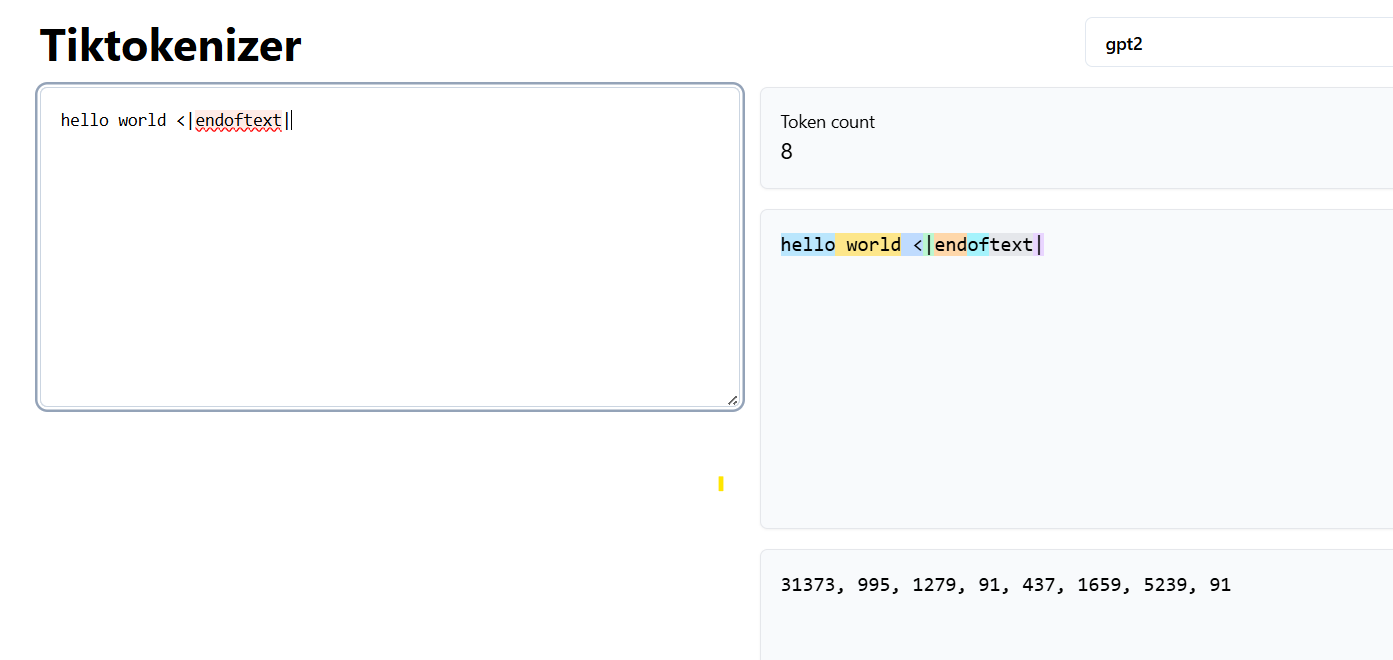

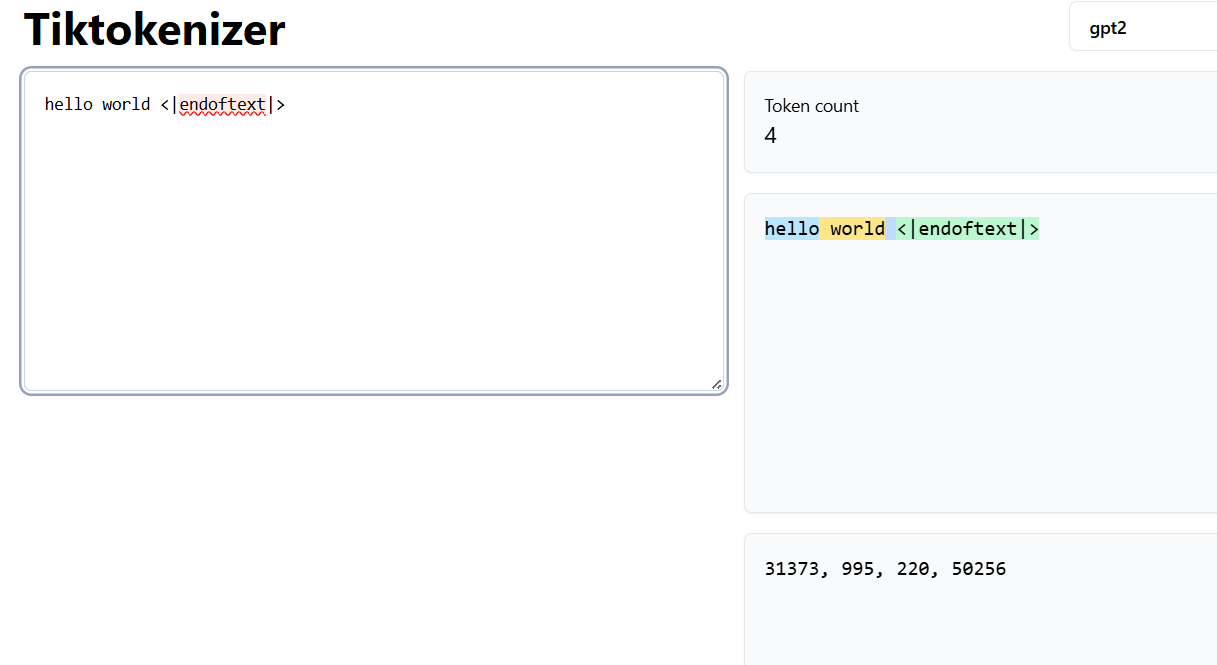

In [16]:
from IPython.display import Image, display
display(Image(filename='et1.png'))
display(Image(filename='et2.png'))

In [17]:
#https://github.com/openai/tiktoken/tree/main?tab=readme-ov-file#extending-tiktoken

# Extending tiktoken
# You may wish to extend tiktoken to support new encodings. There are two ways to do this.

# Create your Encoding object exactly the way you want and simply pass it around.

# cl100k_base = tiktoken.get_encoding("cl100k_base")

# # In production, load the arguments directly instead of accessing private attributes
# # See openai_public.py for examples of arguments for specific encodings
# enc = tiktoken.Encoding(
#     # If you're changing the set of special tokens, make sure to use a different name
#     # It should be clear from the name what behaviour to expect.
#     name="cl100k_im",
#     pat_str=cl100k_base._pat_str,
#     mergeable_ranks=cl100k_base._mergeable_ranks,
#     special_tokens={
#         **cl100k_base._special_tokens,
#         "<|im_start|>": 100264,
#         "<|im_end|>": 100265,
#     }
# )
# Use the tiktoken_ext plugin mechanism to register your Encoding objects with tiktoken.

# This is only useful if you need tiktoken.get_encoding to find your encoding, otherwise prefer option 1.

# To do this, you'll need to create a namespace package under tiktoken_ext.

# Layout your project like this, making sure to omit the tiktoken_ext/__init__.py file:

# my_tiktoken_extension
# ├── tiktoken_ext
# │   └── my_encodings.py
# └── setup.py
# my_encodings.py should be a module that contains a variable named ENCODING_CONSTRUCTORS. This is a dictionary from an encoding name to a function that takes no arguments and returns arguments that can be passed to tiktoken.Encoding to construct that encoding. For an example, see tiktoken_ext/openai_public.py. For precise details, see tiktoken/registry.py.

# Your setup.py should look something like this:

# from setuptools import setup, find_namespace_packages

# setup(
#     name="my_tiktoken_extension",
#     packages=find_namespace_packages(include=['tiktoken_ext*']),
#     install_requires=["tiktoken"],
#     ...
# )
# Then simply pip install ./my_tiktoken_extension and you should be able to use your custom encodings! Make sure not to use an editable install.

In [18]:
#https://arxiv.org/pdf/2207.14255

In [ ]:
1:25:00

In [ ]:
# minbpe exercise
# At this point you have everything you need to build your own GPT-4 tokenizer. This is the exercise progression you may wish to follow. You'll note that it is part of the minbpe repo, which is the solution to that exercise, and is a cleaned up version of the code above.

In [1]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # GPT-4 tokenizer
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")
# match the above for your own tokenizer, and also implement a train() function

[31495, 230, 75265, 243, 92245, 62904, 233, 320, 15339, 304, 16526, 16715]
True


In [3]:
#https://github.com/karpathy/minbpe/blob/master/exercise.md
#https://github.com/karpathy/minbpe



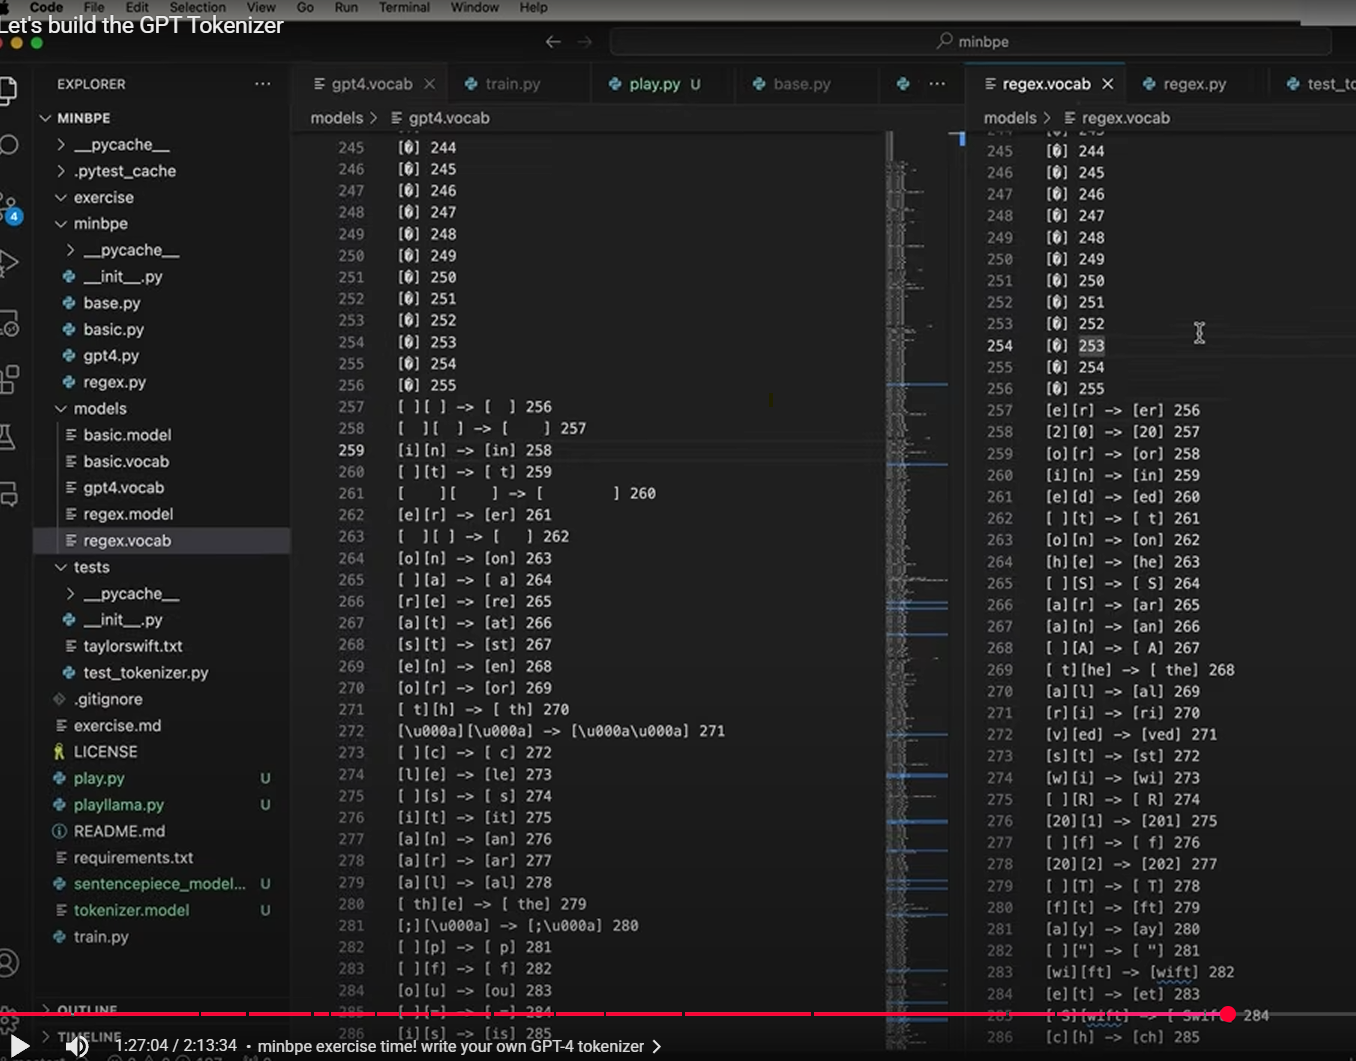

In [5]:
from IPython.display import Image, display
display(Image(filename='trainfun.png'))

In [6]:
#  SentencePiece Tokenizer: Differences and Challenges
# • SentencePiece is a widely-used tokenizer library that supports training and inference, used by models like LLaMA and Mistral.
# • Unlike TikToken, SentencePiece operates directly on Unicode code points (characters) rather than UTF-8 bytes, applying BPE merges at the code point level.
# • Rare code points are handled by byte fallback (byte-level tokenization), which adds complexity and vocabulary size overhead.
# • SentencePiece introduces historical baggage such as the concept of sentences in training, maximum sentence length, and extensive configuration options, which can cause confusion and misconfiguration.
# • It enforces normalization and pre-processing that may not be optimal for raw LLM data, where retaining raw text fidelity may be preferable.
# • Special tokens (e.g., unknown, padding) are required, and the handling of whitespace (e.g., dummy prefix spaces) differs from other tokenizers.
# • The vocabulary order in SentencePiece typically starts with special tokens, followed by byte tokens, merged tokens, and finally individual code point tokens.
# • Decoding whitespace to visible characters (e.g., underscore) and prefix spaces modifies tokenization behavior and can affect model training and inference.
# • SentencePiece’s documentation and complexity make it less user-friendly and less elegant compared to byte-level BPE tokenizers like TikToken.


In [7]:
# sentencepiece
# Commonly used because (unlike tiktoken) it can efficiently both train and inference BPE tokenizers. It is used in both Llama and Mistral series.

# sentencepiece on Github link.

# The big difference: sentencepiece runs BPE on the Unicode code points directly! It then has an option character_coverage for what to do with very very rare codepoints that appear very few times, and it either maps them onto an UNK token, or if byte_fallback is turned on, it encodes them with utf-8 and then encodes the raw bytes instead.

# TLDR:

# tiktoken encodes to utf-8 and then BPEs bytes
# sentencepiece BPEs the code points and optionally falls back to utf-8 bytes for rare code points (rarity is determined by character_coverage hyperparameter), which then get translated to byte tokens.
# (Personally I think the tiktoken way is a lot cleaner...)

In [ ]:

import wget
url = 'https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json'
filename = wget.download(url)
print(f"Downloaded file: {filename}")

In [11]:
import sentencepiece as spm

In [12]:
# write a toy.txt file with some random text
with open("toy.txt", "w", encoding="utf-8") as f:
  f.write("SentencePiece is an unsupervised text tokenizer and detokenizer mainly for Neural Network-based text generation systems where the vocabulary size is predetermined prior to the neural model training. SentencePiece implements subword units (e.g., byte-pair-encoding (BPE) [Sennrich et al.]) and unigram language model [Kudo.]) with the extension of direct training from raw sentences. SentencePiece allows us to make a purely end-to-end system that does not depend on language-specific pre/postprocessing.")

In [13]:
# Docs for sentencepiece options:

# markdown
# protobuf
#https://github.com/google/sentencepiece/blob/master/src/sentencepiece_model.proto#L193
#https://github.com/google/sentencepiece/blob/master/doc/options.md

In [19]:
# train a sentencepiece model on it
# the settings here are (best effort) those used for training Llama 2
import os

options = dict(
  # input spec
  input="toy.txt",
  input_format="text",
  # output spec
  model_prefix="tok400", # output filename prefix
  # algorithm spec
  # BPE alg
  model_type="bpe",
  vocab_size=400,
  # normalization
  normalization_rule_name="identity", # ew, turn off normalization
  remove_extra_whitespaces=False,
  input_sentence_size=200000000, # max number of training sentences
  max_sentence_length=4192, # max number of bytes per sentence
  seed_sentencepiece_size=1000000,
  shuffle_input_sentence=True,
  # rare word treatment
  character_coverage=0.99995,
  byte_fallback=False,
  # merge rules
  split_digits=True,
  split_by_unicode_script=True,
  split_by_whitespace=True,
  split_by_number=True,
  max_sentencepiece_length=16,
  add_dummy_prefix=True,
  allow_whitespace_only_pieces=True,
  # special tokens
  unk_id=0, # the UNK token MUST exist
  bos_id=1, # the others are optional, set to -1 to turn off
  eos_id=2,
  pad_id=-1,
  # systems
  num_threads=os.cpu_count(), # use ~all system resources
)

spm.SentencePieceTrainer.train(**options)
#rules so I think this is a little bit equivalent to tick token using the regular expression to split up categories there's like kind of equivalence of it if you squint T it in sentence piece where you can also for example split up split up the digits uh and uh so on there's a few more things here that I'll come back to in a bit and then there are some special tokens that you can indicate and it hardcodes the UN token the beginning of sentence end of sentence and a pad token um and the UN

#token must exist for my understanding and then some some things so we can train and when when I press train it's going to create this file talk 400. model and talk 400. wab I can then load the model file and I can inspect the vocabulary off it and so we trained vocab size 400 on this text here and these are the individual pieces the individual tokens that sentence piece will create so in the beginning we see that we have the an token uh with the ID zero then we have the beginning of sequence end of sequence one and two and
#then we said that the pad ID is negative 1 so we chose not to use it so there's no pad ID here then these are individual bite tokens so here we saw that bite fallback in llama was turned on so it's true so what follows are going to be the 256 bite tokens and these are their IDs and then at the bottom after the bite tokens come the merges and these are the parent nodes in the merges so we're not seeing the children we're just seeing the parents and their ID and then after the merges comes eventually the individual

# tokens and their IDs and so these are the individual tokens so these are the individual code Point tokens if you will and they come at the end so that is the ordering with which sentence piece sort of like represents its vocabularies it starts with special tokens then the bike tokens then the merge tokens and then the individual codo tokens and all these raw codepoint to tokens are the ones that it encountered in the training set so those individual code points are all the the entire set of code points
#that occurred here so those all get put in there and then those that are extremely rare as determined by character coverage so if a code Point occurred only a single time out of like a million um sentences or something like that then it would be ignored and it would not be added to our uh vocabulary once we have a vocabulary we can encode into IDs and we can um sort of get a list and then here I am also decoding the indiv idual tokens back into little pieces as they call it so let's take a look at what happened here hello space

#https://github.com/google/sentencepiece/blob/master/doc/options.md

In [22]:
sp = spm.SentencePieceProcessor()
sp.load('tok400.model')
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.get_piece_size())]
vocab
#byte_fallback=False

[['<unk>', 0],
 ['<s>', 1],
 ['</s>', 2],
 ['<0x00>', 3],
 ['<0x01>', 4],
 ['<0x02>', 5],
 ['<0x03>', 6],
 ['<0x04>', 7],
 ['<0x05>', 8],
 ['<0x06>', 9],
 ['<0x07>', 10],
 ['<0x08>', 11],
 ['<0x09>', 12],
 ['<0x0A>', 13],
 ['<0x0B>', 14],
 ['<0x0C>', 15],
 ['<0x0D>', 16],
 ['<0x0E>', 17],
 ['<0x0F>', 18],
 ['<0x10>', 19],
 ['<0x11>', 20],
 ['<0x12>', 21],
 ['<0x13>', 22],
 ['<0x14>', 23],
 ['<0x15>', 24],
 ['<0x16>', 25],
 ['<0x17>', 26],
 ['<0x18>', 27],
 ['<0x19>', 28],
 ['<0x1A>', 29],
 ['<0x1B>', 30],
 ['<0x1C>', 31],
 ['<0x1D>', 32],
 ['<0x1E>', 33],
 ['<0x1F>', 34],
 ['<0x20>', 35],
 ['<0x21>', 36],
 ['<0x22>', 37],
 ['<0x23>', 38],
 ['<0x24>', 39],
 ['<0x25>', 40],
 ['<0x26>', 41],
 ['<0x27>', 42],
 ['<0x28>', 43],
 ['<0x29>', 44],
 ['<0x2A>', 45],
 ['<0x2B>', 46],
 ['<0x2C>', 47],
 ['<0x2D>', 48],
 ['<0x2E>', 49],
 ['<0x2F>', 50],
 ['<0x30>', 51],
 ['<0x31>', 52],
 ['<0x32>', 53],
 ['<0x33>', 54],
 ['<0x34>', 55],
 ['<0x35>', 56],
 ['<0x36>', 57],
 ['<0x37>', 58],
 ['<0x38>', 5

In [16]:
ids = sp.encode("hello 안녕하세요")
print(ids)

[362, 378, 361, 372, 358, 362, 239, 152, 139, 238, 136, 152, 240, 152, 155, 239, 135, 187, 239, 157, 151]


In [17]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', 'h', 'e', 'l', 'lo', '▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0x84>', '<0xB8>', '<0xEC>', '<0x9A>', '<0x94>']


In [18]:
#on so these are the token IDs we got back and when we look here uh a few things sort of uh jump to mind number one take a look at these characters the Korean characters of course were not part of the training set so sentence piece is encountering code points that it has not seen during training time and those code points do not have a token associated with them so suddenly these are un tokens unknown tokens but because bite fall back as true instead sentence piece falls back to bytes and so it takes this it encodes it with utf8 and
#then it uses these tokens to represent uh those bytes and that's what we are getting sort of here this is the utf8 uh encoding and in this shifted by three uh because of these um special tokens here that have IDs earlier on so that's what happened here now one more thing that um well first before I go on with respect to the bitef back let me remove bite foldback if this is false what's going to happen let's retrain so the first thing that happened is all the bite tokens disappeared right
#and now we just have the merges and we have a lot more merges now because we have a lot more space because we're not taking up space in the wab size uh with all the bytes and now if we encode this we get a zero so this entire string here suddenly there's no bitef back so this is unknown and unknown is an and so this is zero because the an token is token zero and you have to keep in mind that this would feed into your uh language model so what is a language model supposed to do when all kinds of


In [21]:
# train a sentencepiece model on it
# the settings here are (best effort) those used for training Llama 2
import os

options = dict(
  # input spec
  input="toy.txt",
  input_format="text",
  # output spec
  model_prefix="tok400", # output filename prefix
  # algorithm spec
  # BPE alg
  model_type="bpe",
  vocab_size=400,
  # normalization
  normalization_rule_name="identity", # ew, turn off normalization
  remove_extra_whitespaces=False,
  input_sentence_size=200000000, # max number of training sentences
  max_sentence_length=4192, # max number of bytes per sentence
  seed_sentencepiece_size=1000000,
  shuffle_input_sentence=True,
  # rare word treatment
  character_coverage=0.99995,
  byte_fallback=True,
  # merge rules
  split_digits=True,
  split_by_unicode_script=True,
  split_by_whitespace=True,
  split_by_number=True,
  max_sentencepiece_length=16,
  add_dummy_prefix=True,
  allow_whitespace_only_pieces=True,
  # special tokens
  unk_id=0, # the UNK token MUST exist
  bos_id=1, # the others are optional, set to -1 to turn off
  eos_id=2,
  pad_id=-1,
  # systems
  num_threads=os.cpu_count(), # use ~all system resources
)

spm.SentencePieceTrainer.train(**options)


In [23]:
sp = spm.SentencePieceProcessor()
sp.load('tok400.model')
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.get_piece_size())]
vocab

# byte_fallback=True,

[['<unk>', 0],
 ['<s>', 1],
 ['</s>', 2],
 ['<0x00>', 3],
 ['<0x01>', 4],
 ['<0x02>', 5],
 ['<0x03>', 6],
 ['<0x04>', 7],
 ['<0x05>', 8],
 ['<0x06>', 9],
 ['<0x07>', 10],
 ['<0x08>', 11],
 ['<0x09>', 12],
 ['<0x0A>', 13],
 ['<0x0B>', 14],
 ['<0x0C>', 15],
 ['<0x0D>', 16],
 ['<0x0E>', 17],
 ['<0x0F>', 18],
 ['<0x10>', 19],
 ['<0x11>', 20],
 ['<0x12>', 21],
 ['<0x13>', 22],
 ['<0x14>', 23],
 ['<0x15>', 24],
 ['<0x16>', 25],
 ['<0x17>', 26],
 ['<0x18>', 27],
 ['<0x19>', 28],
 ['<0x1A>', 29],
 ['<0x1B>', 30],
 ['<0x1C>', 31],
 ['<0x1D>', 32],
 ['<0x1E>', 33],
 ['<0x1F>', 34],
 ['<0x20>', 35],
 ['<0x21>', 36],
 ['<0x22>', 37],
 ['<0x23>', 38],
 ['<0x24>', 39],
 ['<0x25>', 40],
 ['<0x26>', 41],
 ['<0x27>', 42],
 ['<0x28>', 43],
 ['<0x29>', 44],
 ['<0x2A>', 45],
 ['<0x2B>', 46],
 ['<0x2C>', 47],
 ['<0x2D>', 48],
 ['<0x2E>', 49],
 ['<0x2F>', 50],
 ['<0x30>', 51],
 ['<0x31>', 52],
 ['<0x32>', 53],
 ['<0x33>', 54],
 ['<0x34>', 55],
 ['<0x35>', 56],
 ['<0x36>', 57],
 ['<0x37>', 58],
 ['<0x38>', 5

In [24]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', 'h', 'e', 'l', 'lo', '▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0x84>', '<0xB8>', '<0xEC>', '<0x9A>', '<0x94>']


In [25]:
# Llama 2 tokenizer proto If you'd like to export the raw protocol buffer for the tokenizer.model released by meta, this is a helpful issue. And this is the result:

# normalizer_spec {
#   name: "identity"
#   precompiled_charsmap: ""
#   add_dummy_prefix: true
#   remove_extra_whitespaces: false
#   normalization_rule_tsv: ""
# }

# trainer_spec {
#   input: "/large_experiments/theorem/datasets/MERGED/all.test1.merged"
#   model_prefix: "spm_model_32k_200M_charcov099995_allowWSO__v2"
#   model_type: BPE
#   vocab_size: 32000
#   self_test_sample_size: 0
#   input_format: "text"
#   character_coverage: 0.99995
#   input_sentence_size: 200000000
#   seed_sentencepiece_size: 1000000
#   shrinking_factor: 0.75
#   num_threads: 80
#   num_sub_iterations: 2
#   max_sentence_length: 4192
#   shuffle_input_sentence: true
#   max_sentencepiece_length: 16
#   split_by_unicode_script: true
#   split_by_whitespace: true
#   split_by_number: true
#   treat_whitespace_as_suffix: false
#   split_digits: true
#   allow_whitespace_only_pieces: true
#   vocabulary_output_piece_score: true
#   hard_vocab_limit: true
#   use_all_vocab: false
#   byte_fallback: true
#   required_chars: ""
#   unk_id: 0
#   bos_id: 1
#   eos_id: 2
#   pad_id: -1
#   unk_surface: " \342\201\207 "
#   unk_piece: "<unk>"
#   bos_piece: "<s>"
#   eos_piece: "</s>"
#   pad_piece: "<pad>"
#   train_extremely_large_corpus: false
#   enable_differential_privacy: false
#   differential_privacy_noise_level: 0.0
#   differential_privacy_clipping_threshold: 0
# }

In [26]:
# vocab_size
# Q: what should be vocab size?
# Q: how can I increase vocab size?
# A: let's see. Reminder: gpt.py from before.
#https://github.com/karpathy/ng-video-lecture/blob/master/gpt.py

In [27]:
#  Vocabulary Size: Trade-offs and Model Implications
# • Vocabulary size affects the Transformer architecture mainly in the token embedding table and the final linear projection (LM head) layer, both scaling with vocabulary size.
# • Larger vocabularies increase model size and computation cost but reduce sequence length by merging longer chunks, allowing more context to be processed.
# • Excessively large vocabularies risk undertraining individual token embeddings due to lower token frequency per token.
# • Smaller vocabularies result in longer sequences and potentially less efficient processing.
# • Vocabulary size is a hyperparameter tuned empirically; modern state-of-the-art models use vocabularies on the order of ~50K to 100K tokens.
# • Extending vocabulary size after pretraining (e.g., to add new special tokens) is common and requires minor model surgery (embedding and output layer resizing).
# • Parameter-efficient fine-tuning techniques can optimize embedding vectors of new tokens (e.g., “gist tokens”) without retraining the entire model.


In [29]:
#want to revisit this issue in a bit more detail of how we should set the vocap size and what are some of the considerations around it so for this I'd like to go back to the model architecture that we developed in the last video when we built the GPT from scratch so this here was uh the file that we built in the previous video and we defined the Transformer model and and let's specifically look at Bap size and where it appears in this file so here we Define the voap size uh at this time it
#was 65 or something like that extremely small number so this will grow much larger you'll see that Bap size doesn't come up too much in most of these layers the only place that it comes up to is in exactly these two places here so when we Define the language model there's the token embedding table which is this two-dimensional array where the vocap size is basically the number of rows and uh each vocabulary element each token has a vector that we're going to train using back propagation that Vector is of
#size and embed which is number of channels in the Transformer and basically as voap size increases this embedding table as I mentioned earlier is going to also grow we're going to be adding rows in addition to that at the end of the Transformer there's this LM head layer which is a linear layer and you'll notice that that layer is used at the very end to produce the logits uh which become the probabilities for the next token in sequence and so intuitively we're trying to produce a
#probability for every single token that might come next at every point in time of that Transformer and if we have more and more tokens we need to produce more and more probabilities so every single token is going to introduce an additional dot product that we have to do here in this linear layer for this final layer in a Transformer so why can't vocap size be infinite why can't we grow to Infinity well number one your token embedding table is going to grow uh your linear layer is going to grow so we're going to
#be doing a lot more computation here because this LM head layer will become more computational expensive number two because we have more parameters we could be worried that we are going to be under trining some of these parameters so intuitively if you have a very large vocabulary size say we have a million uh tokens then every one of these tokens is going to come up more and more rarely in the training data because there's a lot more other tokens all over the place and so we're going to
#be seeing fewer and fewer examples uh for each individual token and you might be worried that basically the vectors associated with every token will be undertrained as a result because they just don't come up too often and they don't participate in the forward backward pass in addition to that as your vocab size grows you're going to start shrinking your sequences a lot right and that's really nice because that means that we're going to be attending to more and more text so that's nice but also you might be
#worrying that two large of chunks are being squished into single tokens and so the model just doesn't have as much of time to think per sort of um some number of characters in the text or you can think about it that way right so basically we're squishing too much information into a single token and then the forward pass of the Transformer is not enough to actually process that information appropriately and so these are some of the considerations you're thinking about when you're designing the
#vocab size as I mentioned this is mostly an empirical hyperparameter and it seems like in state-of-the-art architectures today this is usually in the high 10,000 or somewhere around 100,000 today and the next consideration I want to briefly talk about is what if we want to take a pre-trained model and we want to extend the vocap size and this is done fairly commonly actually so for example when you're doing fine-tuning for cha GPT um a lot more new special tokens get introduced on top of the base model to
#maintain the metadata and all the structure of conversation objects between a user and an assistant so that takes a lot of special tokens you might also try to throw in more special tokens for example for using the browser or any other tool and so it's very tempting to add a lot of tokens for all kinds of special functionality so if you want to be adding a token that's totally possible Right all we have to do is we have to resize this embedding so we have to add rows we would initialize these uh
#parameters from scratch to be small random numbers and then we have to extend the weight inside this linear uh so we have to start making dot products um with the associated parameters as well to basically calculate the probabilities for these new tokens so both of these are just a resizing operation it's a very mild model surgery and can be done fairly easily and it's quite common that basically you would freeze the base model you introduce these new parameters and then you only train these new

#learn to compress prompts with gist tokens 
#https://arxiv.org/pdf/2304.08467


In [30]:
# Multimodal Tokenization and Transformer Input Representation
# • Transformers can be adapted to handle multiple modalities (text, images, video, audio) by tokenizing them into discrete or soft tokens and feeding them as a single token sequence.
# • This approach allows reusing the same Transformer architecture without fundamental changes, treating all modalities uniformly as token sequences.
# • Examples include image tokens (e.g., visual patches) and video tokens, enabling autoregressive or diffusion modeling in multimodal contexts.
# • This is an active area of research with promising results but beyond the scope of the current video.


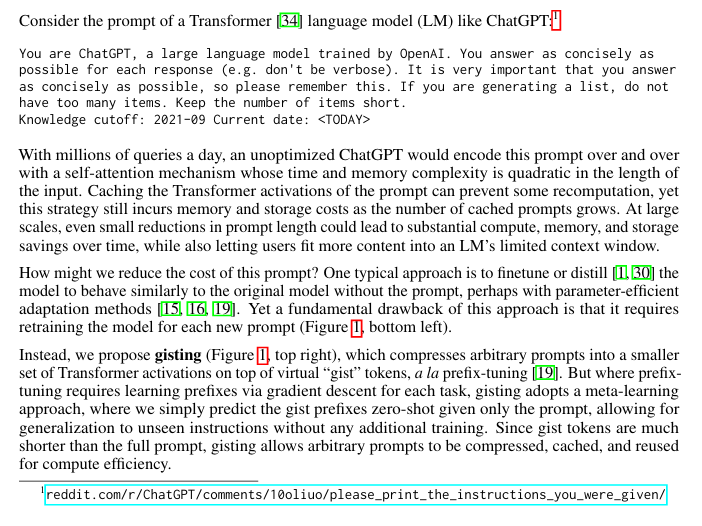

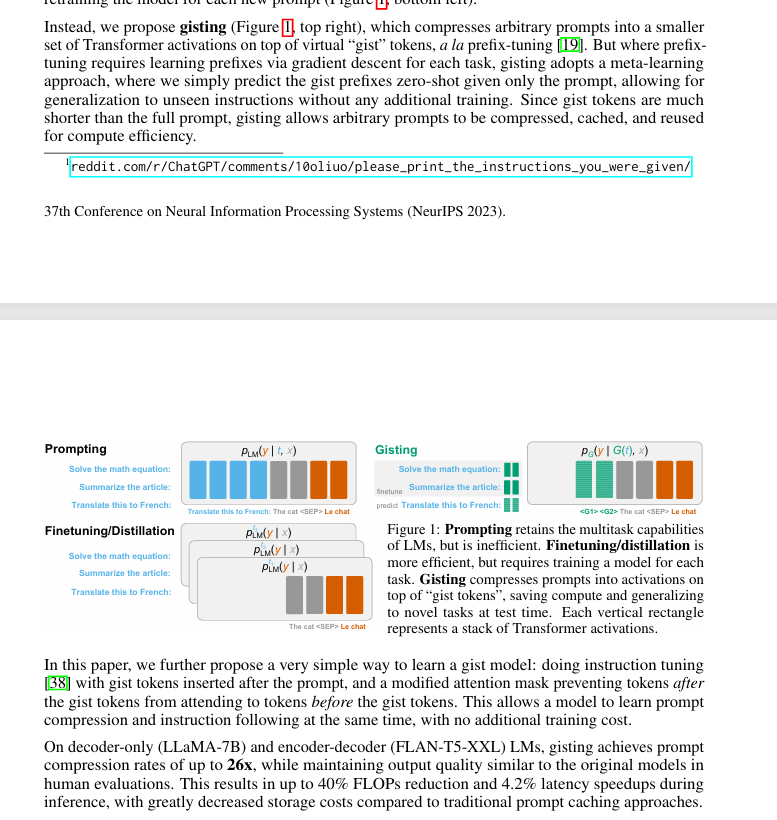

In [32]:
from IPython.display import Image, display
display(Image(filename='gist.png'))
display(Image(filename='gist2.png'))

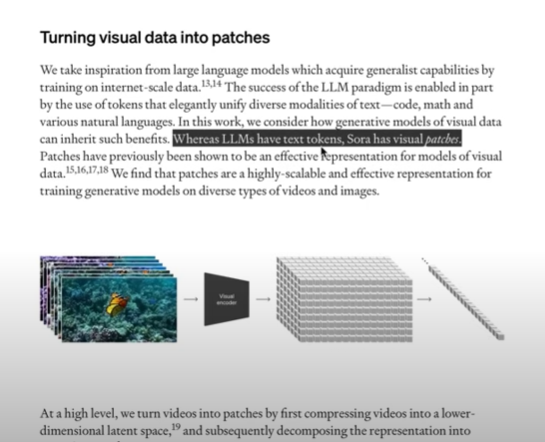

In [35]:
#parameters to introduce new tokens into the architecture um and so you can freeze arbitrary parts of it or you can train arbitrary parts of it and that's totally up to you but basically minor surgery required if you'd like to introduce new tokens and finally I'd like to mention that actually there's an entire design space of applications in terms of introducing new tokens into a vocabulary that go Way Beyond just adding special tokens and special new functionality so just to give you a
#sense of the design space but this could be an entire video just by itself uh this is a paper on learning to compress prompts with what they called uh gist tokens and the rough idea is suppose that you're using language models in a setting that requires very long prompts while these long prompts just slow everything down because you have to encode them and then you have to use them and then you're tending over them and it's just um you know heavy to have very large prompts so instead what they
#do here in this paper is they introduce new tokens and um imagine basically having a few new tokens you put them in a sequence and then you train the model by distillation so you are keeping the entire model Frozen and you're only training the representations of the new tokens their embeddings and you're optimizing over the new tokens such that the behavior of the language model is identical uh to the model that has a very long prompt that works for you and so it's a compression technique of
#compressing that very long prompt into those few new gist tokens and so you can train this and then at test time you can discard your old prompt and just swap in those tokens and they sort of like uh stand in for that very long prompt and have an almost identical performance and so this is one um technique and a class of parameter efficient fine-tuning techniques where most of the model is basically fixed and there's no training of the model weights there's no training of Laura or anything like that of new
from IPython.display import Image, display
display(Image(filename='tt.png'))
#display(Image(filename='gist2.png'))

In [ ]:
# Tokenization Issues Explaining LLM Behavior Anomalies
# • Poor spelling and string manipulation abilities in LLMs often arise because many words or phrases are a single token, limiting character-level reasoning.
# • Arbitrary token boundaries in number tokenization hurt arithmetic performance; numbers can be split inconsistently, confusing the model.
# • Non-English languages often tokenize into many more tokens than English, bloating input sequences and reducing effective context.
# • Inefficient tokenization of whitespace and indentation (e.g., GPT-2 and Python spaces) reduces context length and harms code modeling.
# • Special tokens (e.g., end-of-text) can cause abrupt halting or unexpected behaviors because the model treats them as control signals.
# • Trailing whitespace tokens can cause warnings or degraded performance since spaces are sometimes tokenized as separate tokens, changing token distributions unexpectedly.
# • Unusual or out-of-distribution tokens (e.g., “solid gold Magikarp”) can cause bizarre model outputs due to mismatch between tokenizer vocabulary and training data, resulting in untrained embeddings and undefined model behavior.
# • Format choice (e.g., JSON vs YAML) impacts tokenization efficiency; more compact formats reduce token counts, improving performance and cost.
